In [3]:
# STEP 01: DATA CLEANING & MISSING/CORRUPT FILE INSPECTION
import os
from PIL import Image

# Since our notebook is directly inside the 'Training' folder, '.' checks the current directory
dataset_path = "." 

def step_01_verify_and_clean_data(data_dir):
    print("==================================================")
    print("   STEP 01: DATA CLEANING & INTEGRITY CHECK       ")
    print("==================================================\n")
    
    valid_count = 0
    corrupt_files = []
    class_distribution = {}

    target_classes = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

    # Scan dataset directories to detect corrupt, zero-byte, or missing image headers
    for root, _, files in os.walk(data_dir):#traverse
        for file in files:#iterates
            if file.lower().endswith(('.png', '.jpg', '.jpeg')): #non image file detection
                file_path = os.path.join(root, file)
                folder_name = os.path.basename(root) #get the parent folder name to identify the target class
                
                # Verify structural integrity of each image
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                        valid_count += 1
                        
                        if folder_name in target_classes:
                            class_distribution[folder_name] = class_distribution.get(folder_name, 0) + 1
                except Exception as e:
                    print(f" [CORRUPT IMAGE REMOVED]: {file_path} | Reason: {e}")
                    corrupt_files.append(file_path)

    # Print summary of verification
    print(f"Total Valid Images Verified : {valid_count}")
    print(f"Total Missing/Corrupt Files: {len(corrupt_files)}\n")
    
    print("--- Detected Class Counts ---")
    for cls_name, count in class_distribution.items():
        print(f" • {cls_name:<18}: {count} images")
        
    print("\n--------------------------------------------------")
    if len(corrupt_files) == 0:
        print(" STEP 01 COMPLETE: DATASET CLEAN & READY FOR NORMALIZATION!")
    else:
        print(f" STEP 01 COMPLETE: {len(corrupt_files)} INVALID FILES ISOLATED.")
    print("--------------------------------------------------")

# Run Step 01
step_01_verify_and_clean_data(dataset_path)

   STEP 01: DATA CLEANING & INTEGRITY CHECK       

Total Valid Images Verified : 2870
Total Missing/Corrupt Files: 0

--- Detected Class Counts ---
 • glioma_tumor      : 826 images
 • meningioma_tumor  : 822 images
 • no_tumor          : 395 images
 • pituitary_tumor   : 827 images

--------------------------------------------------
 STEP 01 COMPLETE: DATASET CLEAN & READY FOR NORMALIZATION!
--------------------------------------------------


In [5]:
import os
import glob
from PIL import Image
import numpy as np

# -------------------------------------------------------------
# STEP 02: SPATIAL RESIZING & INPUT SHAPE STANDARDIZATION (PIL)
# -------------------------------------------------------------

def step_02_spatial_resizing(data_dir, target_size=(224, 224)):
    print("==================================================")
    print("   STEP 02: IMAGE RESIZING & DIMENSION INSPECTION ")
    print("==================================================\n")
    
    # Collect sample image paths from subfolders
    sample_images = glob.glob(os.path.join(data_dir, "*", "*.jpg")) + \
                    glob.glob(os.path.join(data_dir, "*", "*.png"))
    
    if not sample_images:
        print("No images found for resizing check.")
        return None, None
    
    # Read the first image using PIL to inspect original shape
    raw_img = Image.open(sample_images[0]) #opens the first image slice from the dataset
    orig_w, orig_h = raw_img.size #get the width and height of uncompressed raw image
    orig_mode = raw_img.mode #read color channels(RGB or L for greyscale)
    
    print(f"Original Sample Image Path  : {sample_images[0]}")
    print(f"Original Image Dimensions   : Width={orig_w}px, Height={orig_h}px, Mode={orig_mode}")
    
    # Resize image to standard 224x224 using Bilinear interpolation
    resized_img = raw_img.resize(target_size, Image.BILINEAR)
    res_w, res_h = resized_img.size
    
    print(f"\nResized Target Dimensions   : Width={res_w}px, Height={res_h}px")
    print("--------------------------------------------------")
    print("STEP 02 COMPLETE: SPATIAL DIMENSIONS STANDARDIZED TO 224x224!")
    
    return raw_img, resized_img

# Run Step 02
raw_sample, resized_sample = step_02_spatial_resizing(".")

   STEP 02: IMAGE RESIZING & DIMENSION INSPECTION 

Original Sample Image Path  : .\glioma_tumor\gg (1).jpg
Original Image Dimensions   : Width=512px, Height=512px, Mode=RGB

Resized Target Dimensions   : Width=224px, Height=224px
--------------------------------------------------
STEP 02 COMPLETE: SPATIAL DIMENSIONS STANDARDIZED TO 224x224!


   STEP 03: PIXEL VALUE NORMALIZATION & SCALING   

1. Raw Pixel Value Range       : Min=0.0, Max=233.0
2. Min-Max Scaled Range        : Min=0.0000, Max=0.9137
3. ImageNet Normalized Range   : Min=-2.1179, Max=2.2566


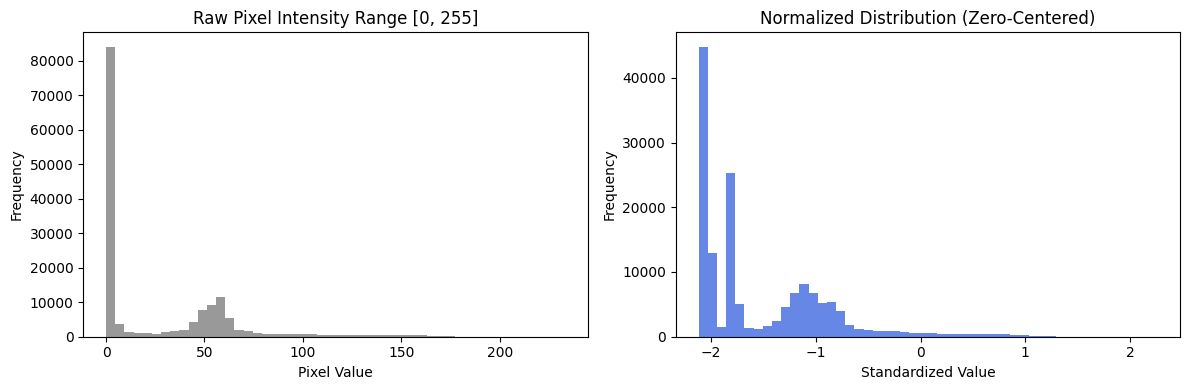

--------------------------------------------------
STEP 03 COMPLETE: PIXEL VALUES NORMALIZED & SCALED!


In [6]:
# STEP 03: MIN-MAX SCALING & IMAGENET NORMALIZATION TRANSFORM
import os
import glob #to retrive file paths matching specified pattern
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def step_03_pixel_normalization(data_dir):
    print("==================================================")
    print("   STEP 03: PIXEL VALUE NORMALIZATION & SCALING   ")
    print("==================================================\n")
    
    # 1. Fetch sample MRI slice
    sample_images = glob.glob(os.path.join(data_dir, "*", "*.jpg")) + \
                    glob.glob(os.path.join(data_dir, "*", "*.png"))
    
    raw_img = Image.open(sample_images[0]).convert("RGB").resize((224, 224))
    raw_np = np.array(raw_img, dtype=np.float32) # Range: [0.0, 255.0]
    
    # 2. Min-Max Scaling to [0.0, 1.0]
    scaled_np = raw_np / 255.0
    
    # 3. ImageNet Standardization (Zero-Centered: Mean & Std)
    imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    imagenet_std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    
    normalized_np = (scaled_np - imagenet_mean) / imagenet_std
    
    print(f"1. Raw Pixel Value Range       : Min={raw_np.min():.1f}, Max={raw_np.max():.1f}")
    print(f"2. Min-Max Scaled Range        : Min={scaled_np.min():.4f}, Max={scaled_np.max():.4f}")
    print(f"3. ImageNet Normalized Range   : Min={normalized_np.min():.4f}, Max={normalized_np.max():.4f}")
    
    # 4. Generate & Display Histogram Plot for Viva Defense
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Raw Histogram
    axes[0].hist(raw_np.ravel(), bins=50, color='gray', alpha=0.8)
    axes[0].set_title("Raw Pixel Intensity Range [0, 255]")
    axes[0].set_xlabel("Pixel Value")
    axes[0].set_ylabel("Frequency")
    
    # Normalized Histogram
    axes[1].hist(normalized_np.ravel(), bins=50, color='royalblue', alpha=0.8)
    axes[1].set_title("Normalized Distribution (Zero-Centered)")
    axes[1].set_xlabel("Standardized Value")
    axes[1].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()
    
    print("--------------------------------------------------")
    print("STEP 03 COMPLETE: PIXEL VALUES NORMALIZED & SCALED!")

# Execute Step 03
step_03_pixel_normalization(".")

   STEP 04: EXPLORATORY DATA ANALYSIS (EDA)       


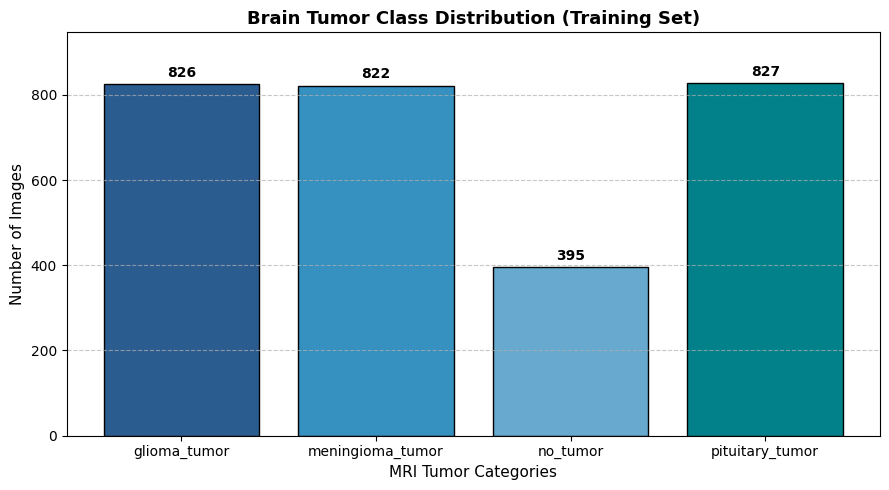

--- EDA Analytical Summary ---
• Majority Class : pituitary_tumor (827 images)
• Minority Class : no_tumor (395 images)
• Class Imbalance Rationale: 'no_tumor' has fewer samples compared to tumor classes,
  requiring Macro F1-Score evaluation and spatial data augmentation during training.
--------------------------------------------------
STEP 04 COMPLETE: CLASS DISTRIBUTION PLOT GENERATED!


In [9]:
# STEP 04: EXPLORATORY DATA ANALYSIS (CLASS DISTRIBUTION PLOT)
import os
import glob
import matplotlib.pyplot as plt

def step_04_class_distribution_eda(data_dir):
    print("==================================================")
    print("   STEP 04: EXPLORATORY DATA ANALYSIS (EDA)       ")
    
    target_classes = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
    class_counts = {}

    for cls in target_classes:
        cls_path = os.path.join(data_dir, cls)
        if os.path.exists(cls_path):
            images = glob.glob(os.path.join(cls_path, "*.jpg")) + glob.glob(os.path.join(cls_path, "*.png"))
            class_counts[cls] = len(images)
            
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    # Plot Bar Chart
    plt.figure(figsize=(9, 5))
    bars = plt.bar(classes, counts, color=['#2b5c8f', '#3690c0', '#67a9cf', '#02818a'], edgecolor='black')

    # Add count labels on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 10, int(yval), ha='center', va='bottom', fontweight='bold')

    plt.title("Brain Tumor Class Distribution (Training Set)", fontsize=13, fontweight='bold')
    plt.xlabel("MRI Tumor Categories", fontsize=11)
    plt.ylabel("Number of Images", fontsize=11)
    plt.ylim(0, max(counts) + 120)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

    print("--- EDA Analytical Summary ---")
    print(f"• Majority Class : {classes[counts.index(max(counts))]} ({max(counts)} images)")
    print(f"• Minority Class : {classes[counts.index(min(counts))]} ({min(counts)} images)")
    print("• Class Imbalance Rationale: 'no_tumor' has fewer samples compared to tumor classes,")
    print("  requiring Macro F1-Score evaluation and spatial data augmentation during training.")
    print("--------------------------------------------------")
    print("STEP 04 COMPLETE: CLASS DISTRIBUTION PLOT GENERATED!")
# Execute Step 04
step_04_class_distribution_eda(".")

   STEP 07: CLASS-WISE PIXEL INTENSITY BOXPLOT    

Calculating mean pixel intensity distributions per class...


C:\Users\Z B O O K\AppData\Local\Temp\ipykernel_32720\1374268118.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, patch_artist=True, labels=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'])


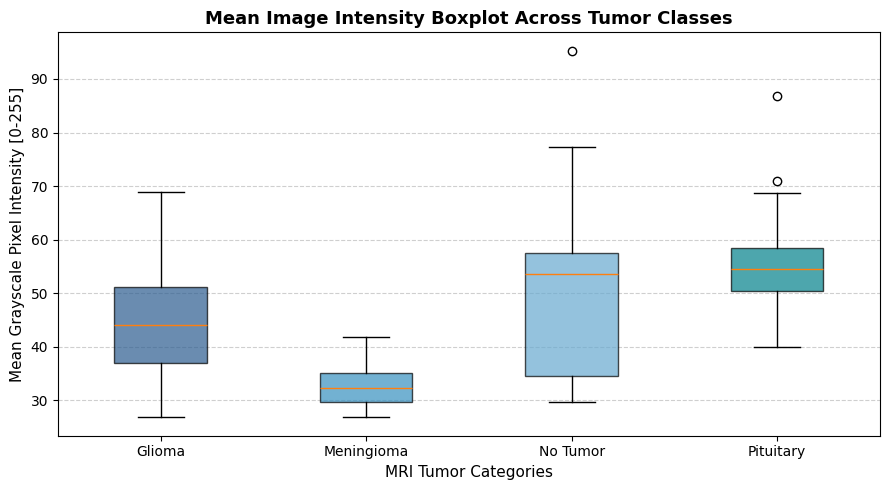

--- EDA Analytical Rationale for Viva ---
• Central Line (Median): Indicates the average baseline illumination level per class.
• Box Height (IQR): Represents variance in overall slice brightness across patients.
• Outliers: Represent unusual high-contrast MRI scans or heavy black padding slices.
• Medical Justification: Demonstrates illumination variances, reinforcing the need for
  ImageNet Normalization to standardize brightness before ConvNeXt-Tiny input.
--------------------------------------------------
STEP 07 COMPLETE: CLASS-WISE BOXPLOT DISPLAYED!
--------------------------------------------------


In [22]:
# STEP 07: EDA - CLASS-WISE PIXEL INTENSITY BOXPLOT ANALYSIS
%matplotlib inline
import os
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def step_07_class_intensity_boxplots(data_dir, samples_per_class=30):
    print("==================================================")
    print("   STEP 07: CLASS-WISE PIXEL INTENSITY BOXPLOT    ")
    print("==================================================\n")
    print("Calculating mean pixel intensity distributions per class...")
    
    target_classes = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
    class_means = {cls: [] for cls in target_classes}
    
    for cls in target_classes:
        cls_path = os.path.join(data_dir, cls)
        images = glob.glob(os.path.join(cls_path, "*.jpg")) + glob.glob(os.path.join(cls_path, "*.png"))
        
        sampled_imgs = images[:samples_per_class]
        
        for img_path in sampled_imgs:
            try:
                with Image.open(img_path) as img:
                    gray_img = img.convert("L")
                    # Compute average brightness intensity for this individual slice
                    class_means[cls].append(np.mean(np.array(gray_img)))
            except Exception:
                continue

    # Plot Boxplots
    plt.figure(figsize=(9, 5))
    data_to_plot = [class_means[cls] for cls in target_classes]
    
    box = plt.boxplot(data_to_plot, patch_artist=True, labels=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'])
    
    colors = ['#2b5c8f', '#3690c0', '#67a9cf', '#02818a']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.title("Mean Image Intensity Boxplot Across Tumor Classes", fontsize=13, fontweight='bold')
    plt.xlabel("MRI Tumor Categories", fontsize=11)
    plt.ylabel("Mean Grayscale Pixel Intensity [0-255]", fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('class_intensity_boxplot.png', bbox_inches='tight')
    plt.show()

    print("--- EDA Analytical Rationale for Viva ---")
    print("• Central Line (Median): Indicates the average baseline illumination level per class.")
    print("• Box Height (IQR): Represents variance in overall slice brightness across patients.")
    print("• Outliers: Represent unusual high-contrast MRI scans or heavy black padding slices.")
    print("• Medical Justification: Demonstrates illumination variances, reinforcing the need for")
    print("  ImageNet Normalization to standardize brightness before ConvNeXt-Tiny input.")
    print("--------------------------------------------------")
    print("STEP 07 COMPLETE: CLASS-WISE BOXPLOT DISPLAYED!")
    print("--------------------------------------------------")

# Execute Step 07
step_07_class_intensity_boxplots(".")